In [16]:
import h5py
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd
def load_dataset():
    fn = 'supplementary_data/train_signs.h5'
    train_dataset = h5py.File(fn, "r")
    X_train = np.array(train_dataset["train_set_x"][:]) # your train set features
    Y_train = np.array(train_dataset["train_set_y"][:]) # your train set labels

    fn = 'supplementary_data/test_signs.h5'
    test_dataset =  h5py.File(fn, "r")
    X_test = np.array(test_dataset["test_set_x"][:]) # your test set features
    Y_test = np.array(test_dataset["test_set_y"][:]) # your test set labels

    classes = np.array(test_dataset["list_classes"][:]) # the list of classes
    
    Y_train = Y_train.reshape((1, Y_train.shape[0]))
    Y_test = Y_test.reshape((1, Y_test.shape[0]))
    
    return X_train, Y_train, X_test, Y_test, classes
train_data, train_labels, test_data, test_labels, classes = load_dataset()

print ('train_data.shape=', train_data.shape)
print ('train_labels.shape=',  train_labels.shape)
print ('test_data.shape=', test_data.shape)
print ('test_labels.shape=', test_labels.shape)

train_data.shape= (1080, 64, 64, 3)
train_labels.shape= (1, 1080)
test_data.shape= (120, 64, 64, 3)
test_labels.shape= (1, 120)


In [17]:
def display_samples_in_grid(X, n_rows, n_cols= None, y = None ):
    if n_cols is None:
        n_cols= n_rows
    indices = np.random.randint(0, len(X),n_rows*n_cols)
    for i in range (n_rows):
        for j in range (n_cols):
            index = n_cols*i+j
            ax = plt.subplot(n_rows,n_cols,index+1)
            ax.imshow(X[indices[index]], cmap='Greys')
            if not (y is None):
                plt.title(y[indices[index]])
            plt.axis('off')


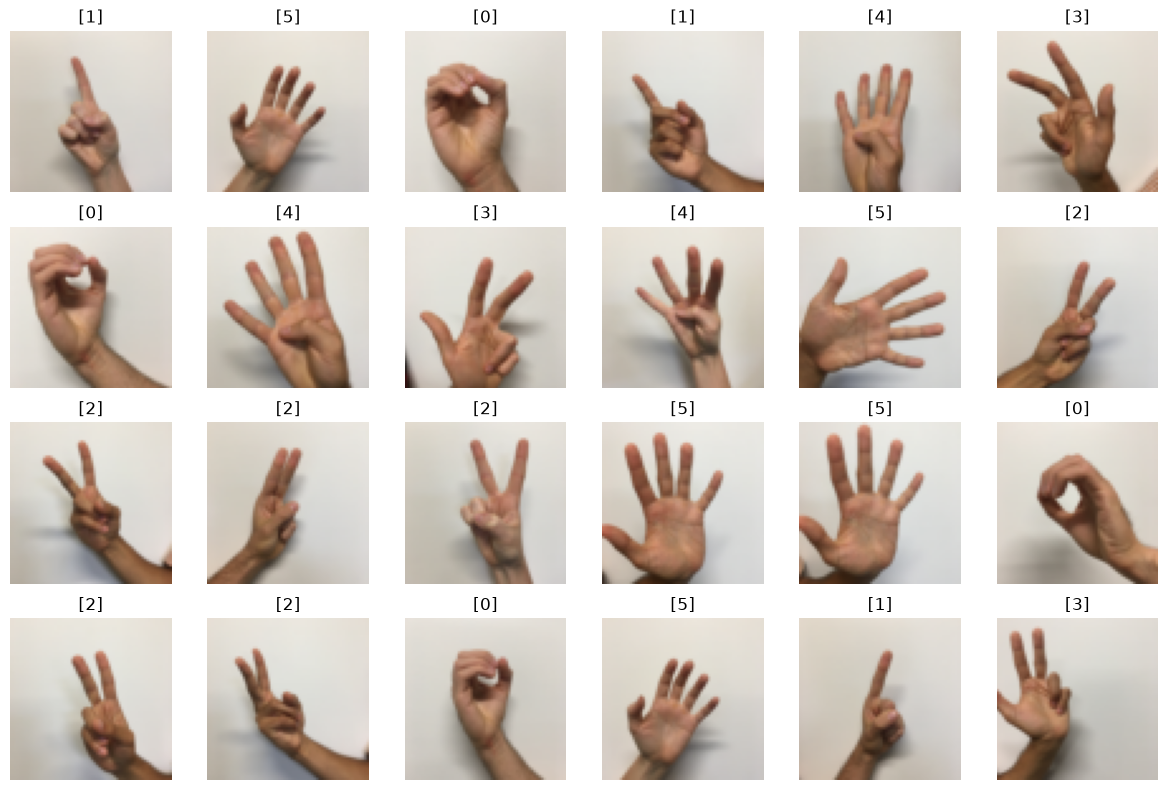

In [18]:
plt.figure(figsize= (12,8))
display_samples_in_grid(train_data, n_rows=4, n_cols=6, y= train_labels.T)
plt.tight_layout(h_pad=1, w_pad=1)

In [19]:
X_train_norm = train_data / 255.0
X_test_norm = test_data / 255.0

y_train = train_labels.T
y_test = test_labels.T

num_classes = len(classes)


In [20]:
from keras.models import Sequential
from keras.layers import Dense, Flatten, Dropout

model = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training Base Model:")
history_base = model.fit(X_train_norm, y_train, epochs=15, validation_data=(X_test_norm, y_test), batch_size=32)


I0000 00:00:1784513463.539088    7763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784513463.539854    7763 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784513463.559464    7763 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784513464.431718    7763 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Training Base Model:
Epoch 1/15


E0000 00:00:1784513467.644207    7763 cuda_platform.cc:57] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
=== Source Location Trace: ===
external/xla/xla/stream_executor/cuda/cuda_status.cc:50



34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2009 - loss: 3.8948 - val_accuracy: 0.1750 - val_loss: 2.0045
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2898 - loss: 1.8297 - val_accuracy: 0.2250 - val_loss: 1.7437
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3500 - loss: 1.6844 - val_accuracy: 0.4417 - val_loss: 1.7066
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4000 - loss: 1.5670 - val_accuracy: 0.4750 - val_loss: 1.4916
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4472 - loss: 1.4712 - val_accuracy: 0.5667 - val_loss: 1.2657
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4926 - loss: 1.3083 - val_accuracy: 0.5917 - val_loss: 1.2057
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5269 - loss: 1.1998 - val_accuracy: 0.5667 - val_loss: 1.1123
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5824 - loss: 1.1206 - val_accuracy: 0.6000 - val_loss: 1.0949
Ep

In [21]:
model_more_layers = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(256, activation='relu'),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_more_layers.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training model with more hidden layers:")
history_layers = model_more_layers.fit(X_train_norm, y_train, epochs=15, validation_data=(X_test_norm, y_test), batch_size=32)


Training model with more hidden layers:
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.1815 - loss: 2.8436 - val_accuracy: 0.1833 - val_loss: 1.8092
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2194 - loss: 1.8755 - val_accuracy: 0.4250 - val_loss: 1.8318
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3296 - loss: 1.7013 - val_accuracy: 0.3417 - val_loss: 1.6696
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3657 - loss: 1.5802 - val_accuracy: 0.4250 - val_loss: 1.4955
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.3667 - loss: 1.5454 - val_accuracy: 0.3917 - val_loss: 1.4453
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4444 - loss: 1.3966 - val_accuracy: 0.4417 - val_loss: 1.3623
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4750 - loss: 1.3407 - val_accuracy: 0.5000 - val_loss: 1.2920
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.4981 -

In [22]:
model_tanh = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(128, activation='tanh'),
    Dense(64, activation='tanh'),
    Dense(num_classes, activation='softmax')
])

model_tanh.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training model with tanh activation:")
history_tanh = model_tanh.fit(X_train_norm, y_train, epochs=15, validation_data=(X_test_norm, y_test), batch_size=32)


Training model with tanh activation:
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1546 - loss: 2.2659 - val_accuracy: 0.1667 - val_loss: 1.8206
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1500 - loss: 1.8163 - val_accuracy: 0.1667 - val_loss: 1.7935
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1639 - loss: 1.8044 - val_accuracy: 0.1667 - val_loss: 1.7930
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1639 - loss: 1.8051 - val_accuracy: 0.1667 - val_loss: 1.7938
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1546 - loss: 1.8050 - val_accuracy: 0.1667 - val_loss: 1.7941
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1472 - loss: 1.8046 - val_accuracy: 0.1667 - val_loss: 1.7940
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1500 - loss: 1.8043 - val_accuracy: 0.1667 - val_loss: 1.7938
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1519 - loss: 1.8

In [23]:
model_dropout = Sequential([
    Flatten(input_shape=(64, 64, 3)),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(num_classes, activation='softmax')
])

model_dropout.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("Training model with Dropout:")
history_dropout = model_dropout.fit(X_train_norm, y_train, epochs=15, validation_data=(X_test_norm, y_test), batch_size=32)


Training model with Dropout:
Epoch 1/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1731 - loss: 3.6182 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 2/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1676 - loss: 1.8111 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 3/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1759 - loss: 1.7920 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 4/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1657 - loss: 1.7920 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 5/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1491 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 6/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1685 - loss: 1.7920 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 7/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1565 - loss: 1.7919 - val_accuracy: 0.1667 - val_loss: 1.7918
Epoch 8/15
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1565 - loss: 1.7919 - va

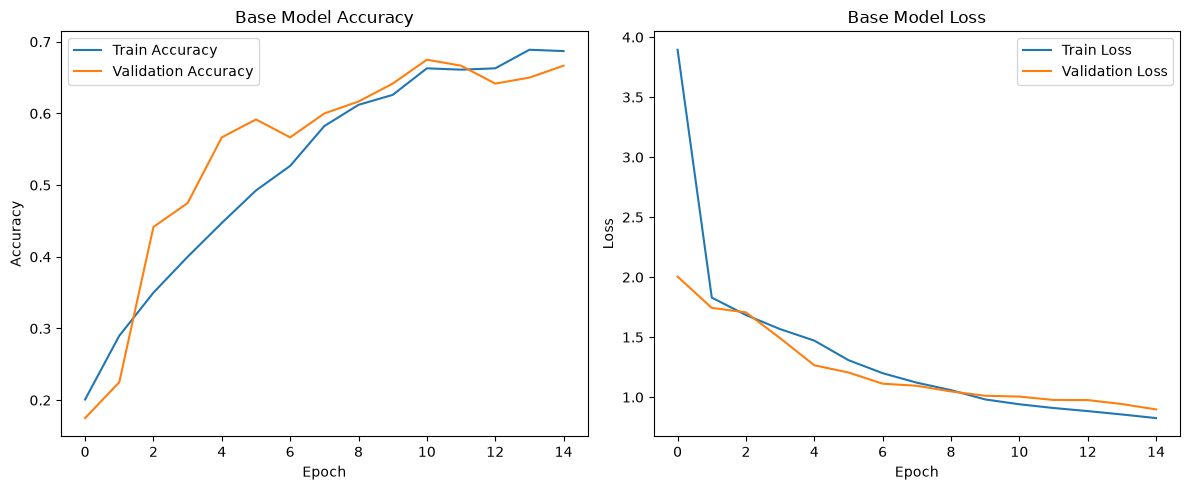

4/4 - 0s - 11ms/step - accuracy: 0.6667 - loss: 0.8979
Final Test Accuracy: 0.6667


In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_base.history['accuracy'], label='Train Accuracy')
plt.plot(history_base.history['val_accuracy'], label='Validation Accuracy')
plt.title('Base Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history_base.history['loss'], label='Train Loss')
plt.plot(history_base.history['val_loss'], label='Validation Loss')
plt.title('Base Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()
test_loss, test_acc = model.evaluate(X_test_norm, y_test, verbose=2)
print(f"Final Test Accuracy: {test_acc:.4f}")